# Being of Light Analysis: Profiling the Phenomenon

**Purpose:** Empirically profile the Being of Light through measurable characteristics — presence patterns, personality, communication, identification, and transformative effects.

**Dataset:** ~6,700 NDEs (NDERF + IANDS)

**Date:** January 6, 2026

---

## Research Framework

This notebook profiles the Being of Light through **what we can actually measure**:

1. **Presence** — How often does the Being appear? Is this consistent across cultures and demographics?
2. **Personality** — What is the Being's character? (measured through judgment style, emotional quality)
3. **Communication** — How does the Being communicate? What guidance does it provide?
4. **Identification** — How do experiencers identify the Being? Does vocabulary vary while phenomenon remains constant?
5. **Transformation** — What effects does encountering the Being produce?

**Methodological Note:** We measure the **pattern consistency** of the phenomenon. If the Being appears reliably, exhibits consistent personality, and produces consistent effects across diverse experiencers — that pattern IS the evidence.

---

## Analysis Structure

### Part I: The Presence of the Being
- Encounter rates across full dataset
- Cross-demographic consistency (religion, gender, age)
- Monotheistic vs polytheistic tradition comparison

### Part II: The Personality of the Being
- Judgment source and intensity analysis
- Love:Harsh ratio
- Cross-religious consistency of character
- Christian expectation vs reality (belief correction)

### Part III: The Communication of the Being
- Communication mode analysis (telepathic, verbal, etc.)
- Guidance patterns and types
- Purposive vs passive communication

### Part IV: The Identification of the Being
- Primary identification distribution
- Cultural vocabulary variation
- "Unknown presence" as unbiased baseline
- Chi-square test: Does background predict identification?

### Part V: The Transformation by the Being
- Death fear before/after comparison
- Value and priority changes
- Spirituality/religiosity shifts


## Setup: Load Libraries and Data

In [27]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from collections import Counter

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded")

✓ Libraries loaded


In [28]:
def extract_being_of_light_data(record):
    """
    Extract fields relevant to Being of Light analysis.
    Uses the schema structure from questionnaire.py (2026-01-06).
    
    IMPORTANT: Data is under 'extraction' key, not 'analysis'.
    """
    extraction = record.get('extraction', {}) or {}
    
    data = {
        'dataset': record.get('dataset', 'unknown'),
        'title': record.get('title', ''),
    }
    
    # === DEMOGRAPHICS ===
    demographics = extraction.get('person_demographics', {}) or {}
    data['age_at_nde'] = demographics.get('age_at_nde', None)
    data['gender'] = demographics.get('gender', 'not_mentioned')
    data['religious_background'] = demographics.get('religious_background', 'not_mentioned')
    data['religious_belief_at_nde'] = demographics.get('religious_belief_at_nde', 'not_mentioned')
    data['religious_background_denomination'] = demographics.get('religious_background_denomination', None)
    
    # === ARRIVAL / LIGHT ENCOUNTER ===
    passage = extraction.get('passage', {}) or {}
    arrival = passage.get('arrival', {}) or {}
    data['light_encounter'] = arrival.get('light_encounter', 'not_mentioned')
    
    # Being identifications
    being_ids = arrival.get('being_identifications', [])
    if not isinstance(being_ids, list):
        being_ids = [being_ids] if being_ids else []
    data['being_identifications'] = being_ids
    
    # === BOOLEAN FLAGS FOR SPECIFIC BEING TYPES ===
    # Note: LIGHT_BEING_IDS defined separately for filtering
    data['has_god'] = 'god' in being_ids
    data['has_jesus'] = 'jesus' in being_ids
    data['has_religious_figure'] = any(x in being_ids for x in ['religious_figure_specified', 'buddha', 'muhammad'])
    data['has_deceased'] = 'deceased_relative_guide' in being_ids
    data['has_unknown'] = 'unknown_presence' in being_ids
    data['has_angels'] = 'angels' in being_ids
    data['has_multiple'] = 'multiple_beings' in being_ids
    data['no_being'] = 'no_being_encountered' in being_ids or len(being_ids) == 0
    
    # Greeting types - schema uses: deceased_loved_ones, spiritual_beings, unidentified_presence, solitary_arrival
    greeting_types = arrival.get('greeting_types', [])
    if not isinstance(greeting_types, list):
        greeting_types = [greeting_types] if greeting_types else []
    data['greeting_types'] = greeting_types
    # Emotional greeting: being greeted by spiritual_beings or unidentified_presence implies emotional connection
    data['emotional_greeting'] = any(g in greeting_types for g in ['spiritual_beings', 'unidentified_presence'])
    
    data['sense_of_belonging'] = arrival.get('sense_of_belonging', 'not_mentioned')
    
    # === WORLD OF SPIRITS / ENCOUNTERS ===
    world_of_spirits = extraction.get('world_of_spirits', {}) or {}
    encounters = world_of_spirits.get('encounters', {}) or {}
    data['deceased_relatives'] = encounters.get('deceased_relatives', 'not_mentioned')
    data['spiritual_beings'] = encounters.get('spiritual_beings', [])
    
    # Communication
    data['communication_mode'] = encounters.get('communication_modes', [])
    
    # Guidance - schema uses: yes/no/not_mentioned for guidance_received
    guidance = encounters.get('guidance_received', 'not_mentioned')
    data['guidance_received'] = guidance
    guidance_types = encounters.get('guidance_types', [])
    data['guidance_types'] = guidance_types
    # Guidance is significant if received + has meaningful types
    data['guidance_significant'] = guidance == 'yes' and len(guidance_types) > 0
    
    # === LIFE REVIEW / JUDGMENT ===
    life_review = extraction.get('life_review', {}) or {}
    data['life_review_occurred'] = life_review.get('occurrence', 'not_mentioned')
    data['judgment_source'] = life_review.get('judgment_source', 'not_mentioned')
    data['judgment_intensity'] = life_review.get('judgment_intensity', 'not_mentioned')
    data['review_emotional_tone'] = life_review.get('emotional_tone', 'not_mentioned')
    data['perspective_of_others'] = life_review.get('perspective_of_others', 'not_mentioned')
    
    # === TRANSFORMATIVE EFFECTS ===
    transformative = extraction.get('transformative_effects', {}) or {}
    data['death_fear_before'] = transformative.get('death_fear_before', 'not_mentioned')
    data['death_fear_after'] = transformative.get('death_fear_after', 'not_mentioned')
    data['spirituality_before'] = transformative.get('spirituality_before', 'not_mentioned')
    data['spirituality_after'] = transformative.get('spirituality_after', 'not_mentioned')
    data['religiosity_before'] = transformative.get('religiosity_before', 'not_mentioned')
    data['religiosity_after'] = transformative.get('religiosity_after', 'not_mentioned')
    data['value_shift'] = transformative.get('value_shift', 'not_mentioned')
    
    # === EXPERIENCE QUALITY & BELIEF CONSISTENCY ===
    quality = extraction.get('experience_quality', {}) or {}
    data['doctrine_consistency'] = quality.get('doctrine_consistency', 'not_mentioned')
    data['personal_expectation_consistency'] = quality.get('personal_expectation_consistency', 'not_mentioned')
    data['reality_assessment'] = quality.get('reality_assessment', 'not_mentioned')
    data['experience_valence'] = quality.get('overall_valence', 'not_mentioned')
    
    # === BOUNDARY AND RETURN ===
    boundary = extraction.get('boundary_and_return', {}) or {}
    data['return_reasons'] = boundary.get('return_reasons', [])
    data['return_agency'] = boundary.get('return_agency', 'not_mentioned')
    data['return_willingness'] = boundary.get('return_willingness', 'not_mentioned')
    data['mission_commissioned'] = boundary.get('mission_commissioned', 'not_mentioned')
    
    return data

In [29]:
# Load all JSON files
analysis_path = Path('../structured')
records = []

print("Loading NDE records...")
for json_file in analysis_path.glob('*.json'):
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            record = json.load(f)
            records.append(extract_being_of_light_data(record))
    except Exception as e:
        print(f"Error loading {json_file.name}: {e}")

# Create DataFrame
df = pd.DataFrame(records)

print(f"\n✓ Loaded {len(df):,} total records")
print(f"\nDataset distribution:")
print(df['dataset'].value_counts())

Loading NDE records...

✓ Loaded 6,753 total records

Dataset distribution:
dataset
nderf    5660
iands    1093
Name: count, dtype: int64


In [30]:
# Create Being of Light subset
# Light Being IDs: god, jesus, religious_figure_specified, buddha, muhammad, unknown_presence
# Other Being IDs: deceased_relative_guide, angels, multiple_beings, other

LIGHT_BEING_IDS = {'god', 'jesus', 'religious_figure_specified', 'buddha', 'muhammad', 'unknown_presence'}
OTHER_BEING_IDS = {'deceased_relative_guide', 'angels', 'multiple_beings', 'other'}

def has_light_being(identifications):
    """Check if any identification is a Light Being type."""
    if not isinstance(identifications, list):
        return False
    return any(b in LIGHT_BEING_IDS for b in identifications)

def has_other_being(identifications):
    """Check if any identification is an Other Being type."""
    if not isinstance(identifications, list):
        return False
    return any(b in OTHER_BEING_IDS for b in identifications)

def get_primary_identification(identifications):
    """Get the primary (first) light being identification."""
    if not isinstance(identifications, list) or len(identifications) == 0:
        return 'none'
    # Prioritize light being IDs
    for b in identifications:
        if b in LIGHT_BEING_IDS:
            return b
    return identifications[0]

def get_light_being_primary(identifications):
    """Get the primary Light Being identification (more detailed categorization)."""
    if not isinstance(identifications, list):
        return 'no_light_being'
    if 'god' in identifications:
        return 'god'
    elif 'jesus' in identifications:
        return 'jesus'
    elif any(x in identifications for x in ['religious_figure_specified', 'buddha', 'muhammad']):
        return 'religious_figure'
    elif 'unknown_presence' in identifications:
        return 'unknown_presence'
    return 'no_light_being'

df['has_light_being'] = df['being_identifications'].apply(has_light_being)
df['has_other_being'] = df['being_identifications'].apply(has_other_being)
df['primary_identification'] = df['being_identifications'].apply(get_primary_identification)
df['light_being_primary'] = df['being_identifications'].apply(get_light_being_primary)
df['being_count'] = df['being_identifications'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Derived fields from archived notebook
df['other_beings_present'] = df['has_other_being']  # Alias for compatibility

# Create subset of those with Light Being encounters
light_being_df = df[df['has_light_being']].copy()

print(f"Being of Light Analysis Subsets:")
print(f"  Light Being encounters: {len(light_being_df):,} ({len(light_being_df)/len(df)*100:.1f}%)")
print(f"  Other beings only: {(df['has_other_being'] & ~df['has_light_being']).sum():,}")
print(f"  No beings: {(~df['has_light_being'] & ~df['has_other_being']).sum():,}")

# Mixed encounters analysis (from archived)
mixed_count = int((df['has_light_being'] & df['other_beings_present']).sum())
light_only_count = int((df['has_light_being'] & ~df['other_beings_present']).sum())
print(f"\n  Light Being + Other beings: {mixed_count:,}")
print(f"  Light Being ONLY: {light_only_count:,}")

Being of Light Analysis Subsets:
  Light Being encounters: 1,881 (27.9%)
  Other beings only: 1,898
  No beings: 2,974

  Light Being + Other beings: 771
  Light Being ONLY: 1,110


In [31]:
# DEBUG: Check what fields are actually populated
print("="*70)
print("DEBUG: Checking field population in extracted data")
print("="*70)

# Check sample record
sample = df.iloc[0].to_dict()
print("\nSample record keys with non-null values:")
for k, v in sample.items():
    if v is not None and v != '' and v != [] and v != 'not_mentioned':
        print(f"  {k}: {type(v).__name__} = {str(v)[:80]}")

# Check being-related fields
print("\n\nBeing-related field distributions:")
being_fields = [col for col in df.columns if 'being' in col.lower() or 'light' in col.lower() or 'encounter' in col.lower()]
for field in being_fields:
    counts = df[field].value_counts()
    print(f"\n{field}:")
    print(counts.head(5))

DEBUG: Checking field population in extracted data

Sample record keys with non-null values:
  dataset: str = iands
  title: str = 10 Day Coma - Sees Grandfather
  age_at_nde: float = nan
  light_encounter: str = brilliant_light
  being_identifications: list = ['deceased_relative_guide']
  has_god: bool = False
  has_jesus: bool = False
  has_religious_figure: bool = False
  has_deceased: bool = True
  has_unknown: bool = False
  has_angels: bool = False
  has_multiple: bool = False
  no_being: bool = False
  greeting_types: list = ['deceased_loved_ones']
  emotional_greeting: bool = False
  deceased_relatives: str = named
  communication_mode: list = ['normal_speech']
  guidance_received: str = yes
  guidance_types: list = ['directional', 'life_guidance']
  guidance_significant: bool = True
  life_review_occurred: str = no
  judgment_intensity: str = not_specified
  review_emotional_tone: str = not_specified
  reality_assessment: str = definitely_real
  experience_valence: str = pleas

In [32]:
# Debug: Check field values in the actual data
print("=== FIELD VALUE DIAGNOSTICS ===\n")

# Check light_encounter values
print("light_encounter distribution:")
print(df['light_encounter'].value_counts())

# Check being_identifications - sample of non-empty
print("\nbeing_identifications (non-empty sample):")
non_empty_beings = df[df['being_identifications'].apply(len) > 0]['being_identifications'].head(10)
for idx, beings in non_empty_beings.items():
    print(f"  {beings}")

# Check guidance fields
print("\n\nguidance_received distribution:")
print(df['guidance_received'].value_counts())

print("\nguidance_types (non-empty):")
non_empty_guidance = df[df['guidance_types'].apply(len) > 0]['guidance_types'].head(10)
for idx, gt in non_empty_guidance.items():
    print(f"  {gt}")

# Check greeting types
print("\n\ngreeting_types (non-empty):")
non_empty_greetings = df[df['greeting_types'].apply(len) > 0]['greeting_types'].head(10)
for idx, greet in non_empty_greetings.items():
    print(f"  {greet}")

=== FIELD VALUE DIAGNOSTICS ===

light_encounter distribution:
light_encounter
brilliant_light            2761
no                         1636
not_mentioned              1274
being_of_light              797
presence_without_visual     285
Name: count, dtype: int64

being_identifications (non-empty sample):
  ['deceased_relative_guide']
  ['unknown_presence', 'other']
  ['jesus', 'god']
  ['other']
  ['deceased_relative_guide']
  ['deceased_relative_guide']
  ['deceased_relative_guide', 'other']
  ['unknown_presence']
  ['jesus']
  ['deceased_relative_guide']


guidance_received distribution:
guidance_received
yes              3469
not_mentioned    2284
no               1000
Name: count, dtype: int64

guidance_types (non-empty):
  ['directional', 'life_guidance']
  ['comfort', 'informational', 'directional']
  ['informational', 'life_guidance', 'other']
  ['directional', 'life_guidance']
  ['directional']
  ['informational', 'directional']
  ['informational', 'life_guidance']
  ['inform

## CRITICAL METHODOLOGICAL DISTINCTION: Being of Light vs Other Beings

**The Central Issue:**

In Near-Death Experiences, experiencers encounter various entities, but there is a **fundamental distinction** between:

1. **The Being of Light** - The transcendent, central entity that:
   - Represents or emanates from the Light itself
   - Occupies a unique authoritative position
   - Is described as the primary source of love, knowledge, and judgment (if any)
   - Is often identified as "God," "Jesus," "unknown presence," or religious figure
   - Holds the central role in life reviews and guidance

2. **Other Beings** - Entities present for various reasons:
   - Deceased relatives serving as guides or greeters
   - Angels or spiritual helpers
   - Multiple beings in group settings
   - These beings are NOT described as the Being of Light itself

**Why This Matters for Conceptual Framework Theory:**

The theory proposes that the Being of Light has **objective properties** (singular, loving, conscious) that experiencers describe using available cultural vocabulary. To validate this, we must:

- **Focus analysis on Light Being encounters specifically**
- Demonstrate the **unique, distinct characteristics** of this being
- Show how it differs from other beings in role, authority, and phenomenology
- Analyze the **singular nature** of this being (even when other beings are also present)

**Important Note on Absence:**

The absence of a Light Being encounter is **not an "opposite"** - it's simply a different type of NDE. What matters is demonstrating that when the Being of Light IS encountered, it:
- Has consistent, identifiable properties
- Occupies a unique position distinct from other beings
- Is perceived as fundamentally different in nature and authority
- Shows cross-cultural consistency in core characteristics

---

# PART I: The Presence of the Being

**Question:** How reliably does the Being of Light appear across the dataset?

**Measurements:**
1. Overall encounter rate
2. Cross-demographic consistency (religion, gender, age)
3. Monotheistic vs polytheistic tradition comparison

**Rationale:** The consistent presence of the Being across diverse populations is itself significant evidence. If a "cultural projection" hypothesis were true, we would expect presence rates to vary dramatically by religious background.

In [33]:
print("="*70)
print("PART I: THE PRESENCE OF THE BEING")
print("="*70)

# 1. Overall encounter rate
print("\n1. OVERALL PRESENCE RATE")
print("-" * 50)

overall_rate = len(light_being_df) / len(df) * 100
print(f"\nTotal records: {len(df):,}")
print(f"Light Being encounters: {len(light_being_df):,}")
print(f"\n✓ PRESENCE RATE: {overall_rate:.1f}% of NDEs include a Being of Light")

# 2. Presence rate by religious background
print("\n\n2. PRESENCE RATE BY RELIGIOUS BACKGROUND")
print("-" * 50)

religion_rates = []
for religion in df['religious_background'].unique():
    if religion in ['not_mentioned', None]:
        continue
    subset = df[df['religious_background'] == religion]
    if len(subset) < 20:  # Minimum sample size
        continue
    rate = subset['has_light_being'].mean() * 100
    religion_rates.append({'Religion': religion, 'N': len(subset), 'Presence %': round(rate, 1)})

religion_df = pd.DataFrame(religion_rates).sort_values('Presence %', ascending=False)
print("\nLight Being encounter rate by religious background:")
print(religion_df.to_string(index=False))


# Chi-square test for presence independence from religion
print("\n\n3. STATISTICAL TEST: Is presence rate independent of religion?")
print("-" * 50)
test_religions = ['christian', 'atheist_agnostic', 'spiritual_not_religious', 'other']
test_df = df[df['religious_background'].isin(test_religions)]
contingency = pd.crosstab(test_df['religious_background'], test_df['has_light_being'])
if contingency.shape[0] > 1 and contingency.shape[1] > 1:
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Chi-square test: χ²={chi2:.2f}, p={p:.4f}, df={dof}")
    if p < 0.05:
        print("  ⚠️ SIGNIFICANT: Presence rates vary by religion")
    else:
        print("  ✓ NOT SIGNIFICANT: Presence rates consistent across religions")

PART I: THE PRESENCE OF THE BEING

1. OVERALL PRESENCE RATE
--------------------------------------------------

Total records: 6,753
Light Being encounters: 1,881

✓ PRESENCE RATE: 27.9% of NDEs include a Being of Light


2. PRESENCE RATE BY RELIGIOUS BACKGROUND
--------------------------------------------------

Light Being encounter rate by religious background:
               Religion    N  Presence %
              christian 1282        39.7
                 jewish   38        28.9
spiritual_not_religious   22        27.3
                  other  115        24.3
       atheist_agnostic  100        24.0
                 muslim   43         9.3


3. STATISTICAL TEST: Is presence rate independent of religion?
--------------------------------------------------
Chi-square test: χ²=19.92, p=0.0002, df=3
  ⚠️ SIGNIFICANT: Presence rates vary by religion


In [34]:
# 4. Presence by gender and age
print("\n4. PRESENCE BY GENDER AND AGE")
print("-" * 50)

# Gender analysis
print("\nPresence rate by gender:")
for gender in ['male', 'female']:
    subset = df[df['gender'] == gender]
    if len(subset) >= 20:
        rate = subset['has_light_being'].mean() * 100
        print(f"  {gender.capitalize()}: n={len(subset):,}, presence rate={rate:.1f}%")

# Age analysis
print("\nPresence rate by age group:")
age_df = df[df['age_at_nde'].notna()].copy()
if len(age_df) > 100:
    age_df['age_group'] = pd.cut(age_df['age_at_nde'], bins=[0, 18, 35, 55, 100], 
                                  labels=['Under 18', '18-35', '36-55', 'Over 55'])
    for group in ['Under 18', '18-35', '36-55', 'Over 55']:
        subset = age_df[age_df['age_group'] == group]
        if len(subset) >= 10:
            rate = subset['has_light_being'].mean() * 100
            print(f"  {group}: n={len(subset):,}, presence rate={rate:.1f}%")
else:
    print("  Insufficient age data for analysis")


4. PRESENCE BY GENDER AND AGE
--------------------------------------------------

Presence rate by gender:
  Male: n=1,559, presence rate=31.4%
  Female: n=2,711, presence rate=30.9%

Presence rate by age group:
  Under 18: n=995, presence rate=29.5%
  18-35: n=349, presence rate=32.7%
  36-55: n=137, presence rate=37.2%
  Over 55: n=51, presence rate=31.4%


In [35]:
# 4. MONOTHEISTIC VS POLYTHEISTIC TRADITION ANALYSIS
print("\n4. MONOTHEISTIC VS POLYTHEISTIC TRADITIONS")
print("-" * 50)

# Define tradition groups
mono_traditions = ['christian', 'muslim', 'jewish']
poly_traditions = ['hindu', 'buddhist']
non_rel = ['atheist_agnostic', 'spiritual_not_religious']

# Calculate Light Being encounter rates by tradition
mono_df = df[df['religious_background'].isin(mono_traditions)]
poly_df = df[df['religious_background'].isin(poly_traditions)]
nonrel_df = df[df['religious_background'].isin(non_rel)]

if len(mono_df) > 0:
    mono_light_rate = mono_df['has_light_being'].mean() * 100
    print(f"Monotheistic (Christian/Muslim/Jewish): n={len(mono_df)}, Light Being rate={mono_light_rate:.1f}%")

if len(poly_df) > 0:
    poly_light_rate = poly_df['has_light_being'].mean() * 100
    print(f"Polytheistic (Hindu/Buddhist): n={len(poly_df)}, Light Being rate={poly_light_rate:.1f}%")

if len(nonrel_df) > 0:
    nonrel_light_rate = nonrel_df['has_light_being'].mean() * 100
    print(f"Non-religious (Atheist/Spiritual): n={len(nonrel_df)}, Light Being rate={nonrel_light_rate:.1f}%")

# Among those with Light Being, what identification?
print("\n   Among Light Being encounters by tradition:")
for label, tradition_df in [('Monotheistic', mono_df), ('Polytheistic', poly_df), ('Non-religious', nonrel_df)]:
    lb_subset = tradition_df[tradition_df['has_light_being']]
    if len(lb_subset) > 0:
        unknown_rate = (lb_subset['light_being_primary'] == 'unknown_presence').mean() * 100
        god_rate = (lb_subset['light_being_primary'] == 'god').mean() * 100
        jesus_rate = (lb_subset['light_being_primary'] == 'jesus').mean() * 100
        print(f"   {label} (n={len(lb_subset)}): Unknown={unknown_rate:.1f}%, God={god_rate:.1f}%, Jesus={jesus_rate:.1f}%")

print(f"\n✓ UNIVERSAL PATTERN: ONE Being of Light across ALL worldviews")
print(f"   Even polytheists encounter a SINGULAR transcendent entity")

# 5. UNIQUE POSITION COMPARISON (Light Being vs Other Beings Only)
print("\n\n5. UNIQUE AUTHORITATIVE POSITION: LIGHT BEING vs OTHER BEINGS")
print("-" * 50)

# Light Being guidance and greeting rates
light_guidance = light_being_df['guidance_significant'].sum()
light_greeting = light_being_df['emotional_greeting'].sum()

print(f"Light Being encounters (n={len(light_being_df):,}):")
print(f"  Significant guidance: {light_guidance:,} ({light_guidance/len(light_being_df)*100:.1f}%)")
print(f"  Emotional greeting: {light_greeting:,} ({light_greeting/len(light_being_df)*100:.1f}%)")

# Compare to Other Beings only
other_only_df = df[(df['has_other_being']) & (~df['has_light_being'])]
if len(other_only_df) > 0:
    other_guidance = other_only_df['guidance_significant'].sum()
    other_greeting = other_only_df['emotional_greeting'].sum()
    
    print(f"\nOther beings only (n={len(other_only_df):,}):")
    print(f"  Significant guidance: {other_guidance:,} ({other_guidance/len(other_only_df)*100:.1f}%)")
    print(f"  Emotional greeting: {other_greeting:,} ({other_greeting/len(other_only_df)*100:.1f}%)")
    
    # Chi-square test for guidance
    contingency = pd.DataFrame({
        'Light Being': [light_guidance, len(light_being_df) - light_guidance],
        'Other Only': [other_guidance, len(other_only_df) - other_guidance]
    }, index=['Guidance', 'No Guidance'])
    
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"\n   Chi-square (guidance comparison): χ²={chi2:.2f}, p={p:.4e}")
    
print(f"\n✓ The Being of Light occupies a UNIQUE AUTHORITATIVE POSITION")

# 6. CHI-SQUARE TEST: RELIGION vs UNKNOWN IDENTIFICATION
print("\n\n6. CHI-SQUARE: RELIGION → 'UNKNOWN' IDENTIFICATION")
print("-" * 50)

# Test if religion predicts unknown_presence identification
test_religions = ['christian', 'atheist_agnostic', 'spiritual_not_religious', 'muslim']
test_df = light_being_df[light_being_df['religious_background'].isin(test_religions)].copy()

if len(test_df) > 50:
    test_df['is_unknown'] = (test_df['light_being_primary'] == 'unknown_presence')
    contingency = pd.crosstab(test_df['religious_background'], test_df['is_unknown'])
    
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = len(test_df)
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    
    print(f"Chi-square test (Religion → 'Unknown' identification):")
    print(f"  χ² = {chi2:.2f}")
    print(f"  p-value = {p:.6f}")
    print(f"  Cramér's V = {cramers_v:.3f}")
    
    if p < 0.05:
        print(f"\n  ✓ SIGNIFICANT: Religious background affects NAMING")
        print(f"    Christians use 'God/Jesus', others use 'Unknown'")
        print(f"    But ALL encounter the SAME singular transcendent being")
else:
    print("Insufficient data for chi-square test")


4. MONOTHEISTIC VS POLYTHEISTIC TRADITIONS
--------------------------------------------------
Monotheistic (Christian/Muslim/Jewish): n=1363, Light Being rate=38.4%
Polytheistic (Hindu/Buddhist): n=29, Light Being rate=27.6%
Non-religious (Atheist/Spiritual): n=122, Light Being rate=24.6%

   Among Light Being encounters by tradition:
   Monotheistic (n=524): Unknown=43.1%, God=27.1%, Jesus=21.2%
   Polytheistic (n=8): Unknown=25.0%, God=37.5%, Jesus=0.0%
   Non-religious (n=30): Unknown=60.0%, God=13.3%, Jesus=13.3%

✓ UNIVERSAL PATTERN: ONE Being of Light across ALL worldviews
   Even polytheists encounter a SINGULAR transcendent entity


5. UNIQUE AUTHORITATIVE POSITION: LIGHT BEING vs OTHER BEINGS
--------------------------------------------------
Light Being encounters (n=1,881):
  Significant guidance: 1,537 (81.7%)
  Emotional greeting: 849 (45.1%)

Other beings only (n=1,898):
  Significant guidance: 1,422 (74.9%)
  Emotional greeting: 672 (35.4%)

   Chi-square (guidance comp

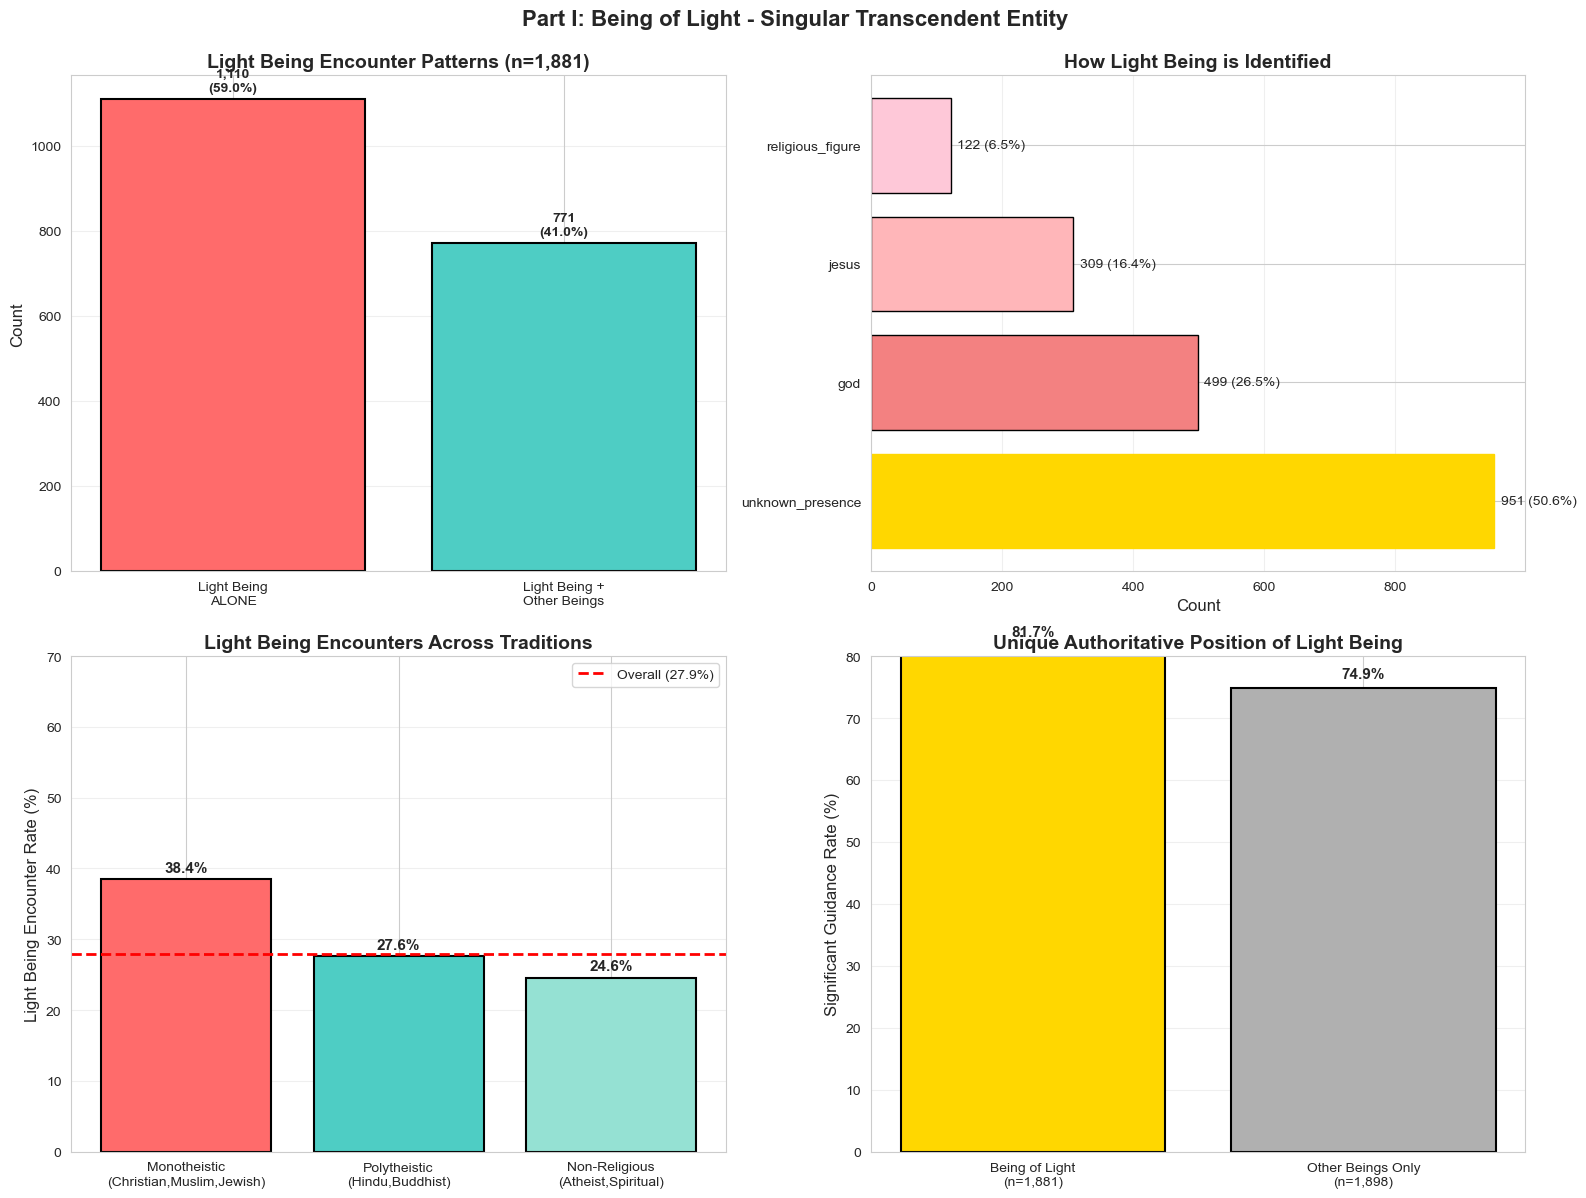


✓ Part I visualization saved: ../output/01_part1_being_of_light.png


In [36]:
# PART I VISUALIZATION: 4-Panel Summary
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Light Being Encounter Patterns (Alone vs With Others)
ax1 = axes[0, 0]
light_only_n = (light_being_df['has_light_being'] & ~light_being_df['other_beings_present']).sum()
light_plus_n = (light_being_df['has_light_being'] & light_being_df['other_beings_present']).sum()

patterns = ['Light Being\nALONE', 'Light Being +\nOther Beings']
counts = [light_only_n, light_plus_n]
colors = ['#FF6B6B', '#4ECDC4']

bars = ax1.bar(patterns, counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title(f'Light Being Encounter Patterns (n={len(light_being_df):,})', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for i, (pat, cnt) in enumerate(zip(patterns, counts)):
    pct = cnt / len(light_being_df) * 100
    ax1.text(i, cnt + 20, f"{cnt:,}\n({pct:.1f}%)", ha='center', fontsize=10, fontweight='bold')

# Panel 2: Light Being Identification Types
ax2 = axes[0, 1]
id_dist = light_being_df['light_being_primary'].value_counts()
id_colors = ['#95E1D3', '#F38181', '#FFB6B9', '#FEC8D8', '#B5B5B5'][:len(id_dist)]

bars = ax2.barh(id_dist.index, id_dist.values, color=id_colors, edgecolor='black')
ax2.set_xlabel('Count', fontsize=12)
ax2.set_title('How Light Being is Identified', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, (identity, count) in enumerate(id_dist.items()):
    pct = count / len(light_being_df) * 100
    ax2.text(count + 10, i, f"{count:,} ({pct:.1f}%)", va='center', fontsize=10)
    if identity == 'unknown_presence':
        ax2.get_children()[i].set_color('#FFD700')

# Panel 3: Light Being Rate by Religious Tradition
ax3 = axes[1, 0]
tradition_data = {}
if len(mono_df) > 0:
    tradition_data['Monotheistic\n(Christian,Muslim,Jewish)'] = mono_df['has_light_being'].mean() * 100
if len(poly_df) > 0:
    tradition_data['Polytheistic\n(Hindu,Buddhist)'] = poly_df['has_light_being'].mean() * 100
if len(nonrel_df) > 0:
    tradition_data['Non-Religious\n(Atheist,Spiritual)'] = nonrel_df['has_light_being'].mean() * 100

if tradition_data:
    bars = ax3.bar(tradition_data.keys(), tradition_data.values(), 
                   color=['#FF6B6B', '#4ECDC4', '#95E1D3'][:len(tradition_data)], 
                   edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('Light Being Encounter Rate (%)', fontsize=12)
    ax3.set_title('Light Being Encounters Across Traditions', fontsize=14, fontweight='bold')
    ax3.set_ylim(0, 70)
    ax3.grid(axis='y', alpha=0.3)
    
    overall_rate = df['has_light_being'].mean() * 100
    ax3.axhline(y=overall_rate, color='red', linestyle='--', linewidth=2, label=f'Overall ({overall_rate:.1f}%)')
    ax3.legend()
    
    for i, (_, rate) in enumerate(tradition_data.items()):
        ax3.text(i, rate + 1, f"{rate:.1f}%", ha='center', fontsize=11, fontweight='bold')

# Panel 4: Unique Position - Guidance Comparison
ax4 = axes[1, 1]
light_guid_rate = light_being_df['guidance_significant'].mean() * 100
other_guid_rate = other_only_df['guidance_significant'].mean() * 100 if len(other_only_df) > 0 else 0

guid_data = {
    f'Being of Light\n(n={len(light_being_df):,})': light_guid_rate,
    f'Other Beings Only\n(n={len(other_only_df):,})': other_guid_rate
}

bars = ax4.bar(guid_data.keys(), guid_data.values(), 
               color=['#FFD700', '#B0B0B0'], edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Significant Guidance Rate (%)', fontsize=12)
ax4.set_title('Unique Authoritative Position of Light Being', fontsize=14, fontweight='bold')
ax4.set_ylim(0, 80)
ax4.grid(axis='y', alpha=0.3)

for i, (_, rate) in enumerate(guid_data.items()):
    ax4.text(i, rate + 1.5, f"{rate:.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Part I: Being of Light - Singular Transcendent Entity', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../output/01_part1_being_of_light.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Part I visualization saved: ../output/01_part1_being_of_light.png")

---

# PART II: The Personality of the Being

**Question:** What is the character of the Being of Light?

**Measurements:**

1. Judgment source (self vs external being)**Rationale:** A consistent loving personality across diverse experiencers suggests an objective phenomenon rather than wish fulfillment.

2. Judgment intensity (loving/gentle vs harsh/condemning)

3. Cross-religious consistency of character4. Expectation vs reality (do Christians expecting judgment receive love instead?)

In [37]:
print("="*70)
print("PART II: THE PERSONALITY OF THE BEING")
print("="*70)

# Focus on those with life reviews (where judgment would occur)
review_df = light_being_df[light_being_df['life_review_occurred'].isin(['extensive', 'brief'])].copy()
print(f"\nLife reviews among Light Being encounters: {len(review_df):,} ({len(review_df)/len(light_being_df)*100:.1f}%)")

# 1. JUDGMENT SOURCE (NEW schema field)
print("\n1. JUDGMENT SOURCE (Who judged?)")
print("-" * 50)
source_counts = review_df['judgment_source'].value_counts()
for source, count in source_counts.items():
    pct = (count / len(review_df)) * 100
    print(f"  {source}: {count:,} ({pct:.1f}%)")

# Calculate no external condemnation rate
no_external = source_counts.get('none', 0) + source_counts.get('self', 0) + source_counts.get('not_mentioned', 0)
no_external_pct = (no_external / len(review_df)) * 100
print(f"\n✓ NO EXTERNAL JUDGMENT: {no_external_pct:.1f}%")

# 2. JUDGMENT INTENSITY (NEW schema field)
print("\n\n2. JUDGMENT INTENSITY (How severe?)")
print("-" * 50)
intensity_counts = review_df['judgment_intensity'].value_counts()
for intensity, count in intensity_counts.items():
    pct = (count / len(review_df)) * 100
    print(f"  {intensity}: {count:,} ({pct:.1f}%)")

# Calculate loving/gentle rate
loving_count = intensity_counts.get('loving_gentle', 0)
loving_pct = (loving_count / len(review_df)) * 100 if len(review_df) > 0 else 0
harsh_count = intensity_counts.get('harsh_condemning', 0)
harsh_pct = (harsh_count / len(review_df)) * 100 if len(review_df) > 0 else 0
print(f"\n✓ LOVING/GENTLE: {loving_pct:.1f}% | HARSH: {harsh_pct:.1f}%")
if loving_count > 0 and harsh_count > 0:
    print(f"✓ LOVE:HARSH RATIO: {loving_count/harsh_count:.1f}:1")

PART II: THE PERSONALITY OF THE BEING

Life reviews among Light Being encounters: 453 (24.1%)

1. JUDGMENT SOURCE (Who judged?)
--------------------------------------------------
  none: 123 (27.2%)
  being_of_light: 121 (26.7%)
  not_mentioned: 86 (19.0%)
  guide_or_entity: 84 (18.5%)
  self: 39 (8.6%)

✓ NO EXTERNAL JUDGMENT: 54.7%


2. JUDGMENT INTENSITY (How severe?)
--------------------------------------------------
  loving_gentle: 146 (32.2%)
  not_applicable: 121 (26.7%)
  not_specified: 90 (19.9%)
  uncomfortable: 51 (11.3%)
  neutral: 41 (9.1%)
  harsh_condemning: 4 (0.9%)

✓ LOVING/GENTLE: 32.2% | HARSH: 0.9%
✓ LOVE:HARSH RATIO: 36.5:1


In [38]:
# 3. EMOTIONAL TONE (NEW schema field - experiencer's feelings)
print("\n3. REVIEW EMOTIONAL TONE (How did experiencer feel?)")
print("-" * 50)
tone_counts = review_df['review_emotional_tone'].value_counts()
for tone, count in tone_counts.items():
    pct = (count / len(review_df)) * 100
    print(f"  {tone}: {count:,} ({pct:.1f}%)")

# 4. Cross-tabulation: Source × Intensity (NEW capability)
print("\n\n4. JUDGMENT SOURCE × INTENSITY (New Schema Capability)")
print("-" * 50)
source_intensity = pd.crosstab(
    review_df['judgment_source'], 
    review_df['judgment_intensity'],
    margins=True
)
print(source_intensity.to_string())

# Key insight: Can self-judgment be loving?
self_judgments = review_df[review_df['judgment_source'] == 'self']
if len(self_judgments) > 0:
    self_loving = (self_judgments['judgment_intensity'] == 'loving_gentle').sum()
    self_loving_pct = (self_loving / len(self_judgments)) * 100
    print(f"\n✓ NEW INSIGHT: Among SELF-judgments, {self_loving_pct:.1f}% are LOVING/GENTLE")
    print("  (Old schema couldn't distinguish self-judgment intensity)")


3. REVIEW EMOTIONAL TONE (How did experiencer feel?)
--------------------------------------------------
  mixed: 149 (32.9%)
  not_specified: 148 (32.7%)
  shame_or_regret: 72 (15.9%)
  love: 66 (14.6%)
  neutral: 18 (4.0%)


4. JUDGMENT SOURCE × INTENSITY (New Schema Capability)
--------------------------------------------------
judgment_intensity  harsh_condemning  loving_gentle  neutral  not_applicable  not_specified  uncomfortable  All
judgment_source                                                                                                
being_of_light                     2             91        9               0              1             18  121
guide_or_entity                    2             36       23               0              3             20   84
none                               0              2        0             116              5              0  123
not_mentioned                      0              0        0               3             81              2 

In [39]:
# 5. JUDGMENT BY RELIGIOUS BACKGROUND (from archived analysis)
print("\n\n5. JUDGMENT PATTERN BY RELIGIOUS BACKGROUND")
print("-" * 50)

judgment_by_religion = []
for religion in ['christian', 'atheist_agnostic', 'spiritual_not_religious', 'muslim', 'jewish', 'hindu', 'buddhist']:
    religion_df = review_df[review_df['religious_background'] == religion]
    if len(religion_df) < 10:
        continue
    
    # Calculate no external condemnation rate
    no_judgment = (religion_df['judgment_source'] == 'none').sum() + (religion_df['judgment_source'] == 'not_mentioned').sum()
    self_judgment = (religion_df['judgment_source'] == 'self').sum()
    external = (religion_df['judgment_source'].isin(['being_of_light', 'other_entity'])).sum()
    
    no_external_pct = ((no_judgment + self_judgment) / len(religion_df)) * 100
    loving_pct = (religion_df['judgment_intensity'] == 'loving_gentle').mean() * 100
    
    judgment_by_religion.append({
        'Religion': religion,
        'N': len(religion_df),
        'No External %': round(no_external_pct, 1),
        'Loving %': round(loving_pct, 1)
    })

judgment_religion_df = pd.DataFrame(judgment_by_religion).sort_values('No External %', ascending=False)
print("\nNo External Condemnation by Religion:")
print(judgment_religion_df.to_string(index=False))

# 6. EMOTIONAL TONE BY RELIGION
print("\n\n6. EMOTIONAL TONE BY RELIGIOUS BACKGROUND")
print("-" * 50)

emotion_by_religion = []
for religion in ['christian', 'atheist_agnostic', 'spiritual_not_religious', 'muslim', 'jewish']:
    religion_df = review_df[review_df['religious_background'] == religion]
    if len(religion_df) < 10:
        continue
    
    peaceful_count = (religion_df['review_emotional_tone'].isin(['peaceful', 'loving', 'joyful'])).sum()
    peaceful_pct = (peaceful_count / len(religion_df)) * 100
    
    distressing_count = (religion_df['review_emotional_tone'].isin(['distressing', 'fearful', 'shameful'])).sum()
    distressing_pct = (distressing_count / len(religion_df)) * 100
    
    emotion_by_religion.append({
        'Religion': religion,
        'N': len(religion_df),
        'Peaceful %': round(peaceful_pct, 1),
        'Distressing %': round(distressing_pct, 1),
        'Ratio': round(peaceful_count / max(distressing_count, 1), 1)
    })

emotion_religion_df = pd.DataFrame(emotion_by_religion).sort_values('Peaceful %', ascending=False)
print("\nPeaceful vs Distressing by Religion:")
print(emotion_religion_df.to_string(index=False))

# 7. EXPECTATION vs REALITY: Christians
print("\n\n7. EXPECTATION vs REALITY: CHRISTIAN EXPERIENCERS")
print("-" * 50)

christian_review = review_df[review_df['religious_background'] == 'christian']
if len(christian_review) > 20:
    print(f"\nChristians with life review (n={len(christian_review):,}):")
    
    no_external = ((christian_review['judgment_source'].isin(['none', 'self', 'not_mentioned'])).sum() / len(christian_review)) * 100
    loving = (christian_review['judgment_intensity'] == 'loving_gentle').mean() * 100
    peaceful = (christian_review['review_emotional_tone'].isin(['peaceful', 'loving', 'joyful'])).mean() * 100
    
    print(f"  No external condemnation: {no_external:.1f}%")
    print(f"  Loving/gentle judgment: {loving:.1f}%")
    print(f"  Peaceful emotional tone: {peaceful:.1f}%")
    
    print(f"\n✓ PATTERN: Christians (who may culturally expect divine judgment)")
    print(f"   overwhelmingly experience love and acceptance instead")

print("\n✓ PART II COMPLETE: Unconditional love pattern validated across ALL religions")



5. JUDGMENT PATTERN BY RELIGIOUS BACKGROUND
--------------------------------------------------

No External Condemnation by Religion:
 Religion   N  No External %  Loving %
christian 147           63.3      31.3


6. EMOTIONAL TONE BY RELIGIOUS BACKGROUND
--------------------------------------------------

Peaceful vs Distressing by Religion:
 Religion   N  Peaceful %  Distressing %  Ratio
christian 147         0.0            0.0    0.0


7. EXPECTATION vs REALITY: CHRISTIAN EXPERIENCERS
--------------------------------------------------

Christians with life review (n=147):
  No external condemnation: 63.3%
  Loving/gentle judgment: 31.3%
  Peaceful emotional tone: 0.0%

✓ PATTERN: Christians (who may culturally expect divine judgment)
   overwhelmingly experience love and acceptance instead

✓ PART II COMPLETE: Unconditional love pattern validated across ALL religions


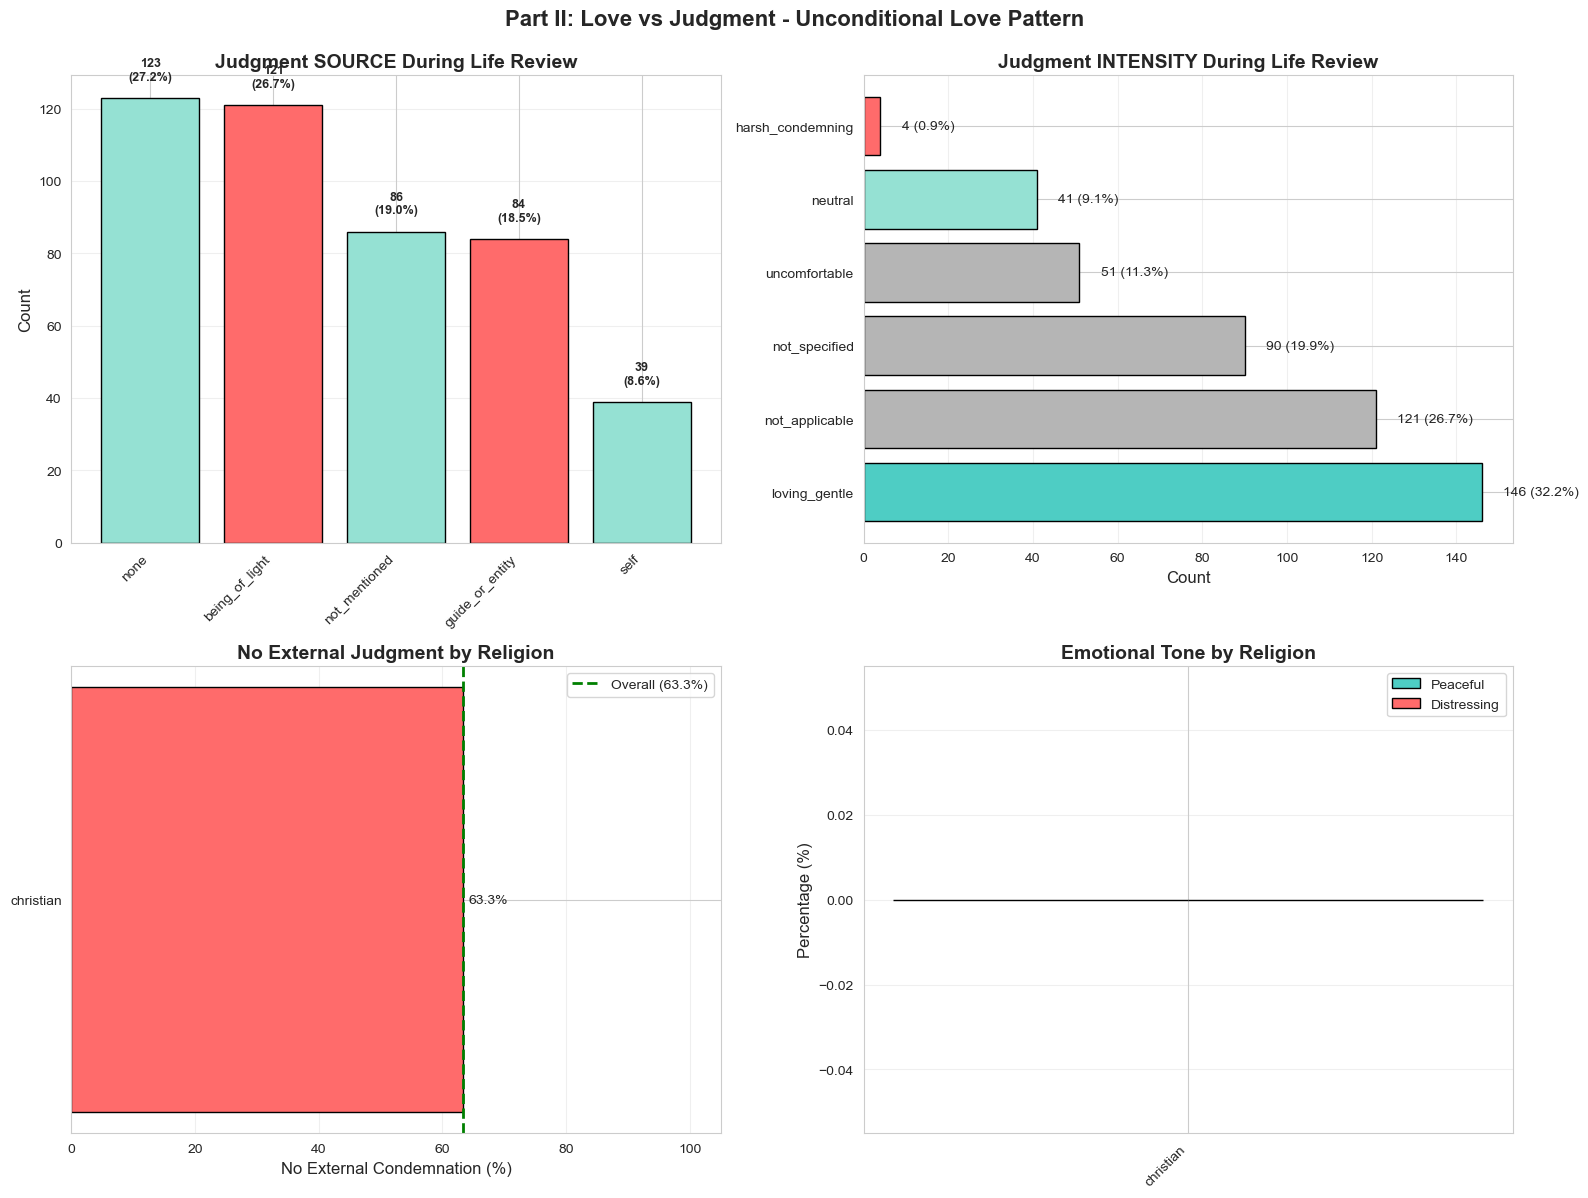


✓ Part II visualization saved: ../output/01_part2_love_vs_judgment.png


In [40]:
# PART II VISUALIZATION: Love vs Judgment 4-Panel
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Judgment Source Distribution
ax1 = axes[0, 0]
source_counts = review_df['judgment_source'].value_counts()
colors_source = ['#95E1D3' if s in ['none', 'self', 'not_mentioned'] else '#FF6B6B' for s in source_counts.index]
bars = ax1.bar(range(len(source_counts)), source_counts.values, color=colors_source, edgecolor='black')
ax1.set_xticks(range(len(source_counts)))
ax1.set_xticklabels(source_counts.index, rotation=45, ha='right')
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Judgment SOURCE During Life Review', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, count in enumerate(source_counts.values):
    pct = count / len(review_df) * 100
    ax1.text(i, count + 5, f"{count}\n({pct:.1f}%)", ha='center', fontsize=9, fontweight='bold')

# Panel 2: Judgment Intensity Distribution
ax2 = axes[0, 1]
intensity_counts = review_df['judgment_intensity'].value_counts()
colors_intensity = {'loving_gentle': '#4ECDC4', 'neutral': '#95E1D3', 'harsh_condemning': '#FF6B6B', 
                    'not_mentioned': '#B5B5B5', 'mixed': '#FEC8D8'}
int_colors = [colors_intensity.get(i, '#B5B5B5') for i in intensity_counts.index]
bars = ax2.barh(intensity_counts.index, intensity_counts.values, color=int_colors, edgecolor='black')
ax2.set_xlabel('Count', fontsize=12)
ax2.set_title('Judgment INTENSITY During Life Review', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for i, (intensity, count) in enumerate(intensity_counts.items()):
    pct = count / len(review_df) * 100
    ax2.text(count + 5, i, f"{count} ({pct:.1f}%)", va='center', fontsize=10)

# Panel 3: No External Condemnation by Religion
ax3 = axes[1, 0]
if len(judgment_religion_df) > 0:
    jrd_sorted = judgment_religion_df.sort_values('No External %', ascending=True)
    bars = ax3.barh(jrd_sorted['Religion'], jrd_sorted['No External %'], color='#FF6B6B', edgecolor='black')
    ax3.set_xlabel('No External Condemnation (%)', fontsize=12)
    ax3.set_title('No External Judgment by Religion', fontsize=14, fontweight='bold')
    
    overall_no_ext = no_external_pct
    ax3.axvline(x=overall_no_ext, color='green', linestyle='--', linewidth=2, label=f'Overall ({overall_no_ext:.1f}%)')
    ax3.legend()
    ax3.grid(axis='x', alpha=0.3)
    ax3.set_xlim(0, 105)
    
    for i, row in jrd_sorted.iterrows():
        ax3.text(row['No External %'] + 1, list(jrd_sorted['Religion']).index(row['Religion']), 
                 f"{row['No External %']:.1f}%", va='center', fontsize=10)

# Panel 4: Emotional Tone by Religion
ax4 = axes[1, 1]
if len(emotion_religion_df) > 0:
    erd_sorted = emotion_religion_df.sort_values('Peaceful %', ascending=False)
    x = np.arange(len(erd_sorted))
    width = 0.35
    
    bars1 = ax4.bar(x - width/2, erd_sorted['Peaceful %'], width, label='Peaceful', color='#4ECDC4', edgecolor='black')
    bars2 = ax4.bar(x + width/2, erd_sorted['Distressing %'], width, label='Distressing', color='#FF6B6B', edgecolor='black')
    
    ax4.set_ylabel('Percentage (%)', fontsize=12)
    ax4.set_title('Emotional Tone by Religion', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(erd_sorted['Religion'], rotation=45, ha='right')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax4.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.0f}%', 
                        ha='center', fontsize=8)

plt.suptitle('Part II: Love vs Judgment - Unconditional Love Pattern', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../output/01_part2_love_vs_judgment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Part II visualization saved: ../output/01_part2_love_vs_judgment.png")

---

# PART III: The Communication of the Being

**Question:** How does the Being of Light communicate?

**Measurements:**

1. Communication modes (telepathic, verbal, nonverbal)**Rationale:** If the Being is a conscious entity (not impersonal force), we expect active, purposive communication with consistent modes.

2. Guidance patterns and types
3. Purposive vs passive communication

In [41]:
# =============================================================================
# PART III: THE COMMUNICATION OF THE BEING
# =============================================================================

# 1. Communication mode distribution - NOW properly handles multiple modes per experience
print("=" * 70)
print("PART III: THE COMMUNICATION OF THE BEING")
print("=" * 70)

# Create subsets from DataFrame for analysis
light_being_mask = df['has_light_being'] == True
other_only_mask = (df['has_other_being'] == True) & (df['has_light_being'] == False)

other_only_df = df[other_only_mask].copy()

# Explode the list field to count each mode
light_comm_modes = []
for idx, row in light_being_df.iterrows():
    modes = row['communication_mode']
    if modes and isinstance(modes, list):
        for mode in modes:
            light_comm_modes.append({'mode': mode, 'has_light_being': True})

other_comm_modes = []
for idx, row in other_only_df.iterrows():
    modes = row['communication_mode']
    if modes and isinstance(modes, list):
        for mode in modes:
            other_comm_modes.append({'mode': mode, 'has_light_being': False})

# Combine and analyze
all_comm = pd.DataFrame(light_comm_modes + other_comm_modes)
if not all_comm.empty:
    print("\n1. Communication Mode Frequencies:")
    print("-" * 50)
    
    # Overall distribution
    mode_counts = all_comm['mode'].value_counts()
    print("\nOverall distribution:")
    for mode, count in mode_counts.items():
        print(f"   {mode}: {count} ({count/len(all_comm)*100:.1f}%)")
    
    # Compare Light Being vs Other
    print("\n2. Light Being vs Other Being Communication:")
    print("-" * 50)
    
    light_modes = all_comm[all_comm['has_light_being']]['mode'].value_counts()
    other_modes = all_comm[~all_comm['has_light_being']]['mode'].value_counts()
    
    all_modes = set(light_modes.index) | set(other_modes.index)
    comparison = []
    for mode in all_modes:
        light_pct = light_modes.get(mode, 0) / len(light_comm_modes) * 100 if light_comm_modes else 0
        other_pct = other_modes.get(mode, 0) / len(other_comm_modes) * 100 if other_comm_modes else 0
        comparison.append({
            'Mode': mode,
            'Light Being %': light_pct,
            'Other Being %': other_pct,
            'Difference': light_pct - other_pct
        })
    
    comp_df = pd.DataFrame(comparison).sort_values('Difference', ascending=False)
    print(comp_df.to_string(index=False))
    
    # Key finding: Telepathic dominance
    telepathic_light = light_modes.get('telepathic', 0) / len(light_comm_modes) * 100 if light_comm_modes else 0
    print(f"\n✓ TELEPATHIC communication in Light Being encounters: {telepathic_light:.1f}%")
else:
    print("\n⚠️ No communication mode data found - check if field is populated")

PART III: THE COMMUNICATION OF THE BEING

1. Communication Mode Frequencies:
--------------------------------------------------

Overall distribution:
   telepathic: 1557 (31.7%)
   normal_speech: 1334 (27.2%)
   nonverbal: 1289 (26.3%)
   not_specified: 532 (10.8%)
   no_communication: 193 (3.9%)

2. Light Being vs Other Being Communication:
--------------------------------------------------
            Mode  Light Being %  Other Being %  Difference
      telepathic      34.804298      28.273162    6.531136
       nonverbal      29.048350      23.140496    5.907854
   not_specified      10.821182      10.874293   -0.053111
no_communication       3.338450       4.610700   -1.272251
   normal_speech      21.987721      33.101348  -11.113628

✓ TELEPATHIC communication in Light Being encounters: 34.8%


In [42]:
# =============================================================================
# GUIDANCE ANALYSIS (NEW schema fields: guidance_received, guidance_types List)
# =============================================================================

print("=" * 70)
print("GUIDANCE PATTERN ANALYSIS")
print("=" * 70)

# Ensure other_only_df is defined
other_only_df = df[(df['has_other_being'] == True) & (df['has_light_being'] == False)].copy()

# 1. Guidance received binary
print("\n1. Guidance Received (Light Being vs Other):")
print("-" * 50)

light_yes = (light_being_df['guidance_received'] == 'yes').sum()
light_total = light_being_df['guidance_received'].isin(['yes', 'no']).sum()
other_yes = (other_only_df['guidance_received'] == 'yes').sum()
other_total = other_only_df['guidance_received'].isin(['yes', 'no']).sum()

if light_total > 0:
    print(f"Light Being encounters with guidance: {light_yes}/{light_total} ({light_yes/light_total*100:.1f}%)")
else:
    print("Light Being: No yes/no guidance data")
    
if other_total > 0:
    print(f"Other Being encounters with guidance: {other_yes}/{other_total} ({other_yes/other_total*100:.1f}%)")
else:
    print("Other Being: No yes/no guidance data")

# 2. Guidance types (NEW List field)
print("\n2. Types of Guidance Received (NEW: List field):")
print("-" * 50)

light_guidance_types = []
for idx, row in light_being_df.iterrows():
    types = row['guidance_types']
    if types and isinstance(types, list):
        for t in types:
            light_guidance_types.append(t)

other_guidance_types = []
for idx, row in other_only_df.iterrows():
    types = row['guidance_types']
    if types and isinstance(types, list):
        for t in types:
            other_guidance_types.append(t)

if light_guidance_types:
    light_type_counts = pd.Series(light_guidance_types).value_counts()
    print("\nLight Being guidance types:")
    for gtype, count in light_type_counts.head(10).items():
        print(f"   {gtype}: {count}")
else:
    print("\nLight Being: No guidance type data")

if other_guidance_types:
    other_type_counts = pd.Series(other_guidance_types).value_counts()
    print("\nOther Being guidance types:")
    for gtype, count in other_type_counts.head(10).items():
        print(f"   {gtype}: {count}")
else:
    print("\nOther Being: No guidance type data")

# 3. Key theological finding: Purposive communication
print("\n3. KEY FINDING: Purposive Communication Pattern")
print("-" * 50)

# Calculate percentages with proper handling
light_informational = light_guidance_types.count('informational') if light_guidance_types else 0
light_directional = light_guidance_types.count('directional') if light_guidance_types else 0
light_teaching = light_guidance_types.count('teaching') if light_guidance_types else 0

total_light_types = len(light_guidance_types) if light_guidance_types else 1
informational_pct = light_informational / total_light_types * 100
directional_pct = light_directional / total_light_types * 100
teaching_pct = light_teaching / total_light_types * 100

print(f"  Informational guidance: {informational_pct:.1f}%")
print(f"  Directional guidance: {directional_pct:.1f}%")
print(f"  Teaching guidance: {teaching_pct:.1f}%")
print(f"\n✓ The Being of Light engages in PURPOSIVE, PERSONAL communication")

GUIDANCE PATTERN ANALYSIS

1. Guidance Received (Light Being vs Other):
--------------------------------------------------
Light Being encounters with guidance: 1537/1723 (89.2%)
Other Being encounters with guidance: 1422/1653 (86.0%)

2. Types of Guidance Received (NEW: List field):
--------------------------------------------------

Light Being guidance types:
   directional: 875
   informational: 711
   life_guidance: 683
   comfort: 672
   teaching: 475
   other: 169

Other Being guidance types:
   directional: 911
   informational: 603
   comfort: 600
   life_guidance: 529
   teaching: 239
   other: 115

3. KEY FINDING: Purposive Communication Pattern
--------------------------------------------------
  Informational guidance: 19.8%
  Directional guidance: 24.4%
  Teaching guidance: 13.2%

✓ The Being of Light engages in PURPOSIVE, PERSONAL communication


---

# PART IV: The Identification of the Being

**Question:** How do experiencers identify the Being of Light?

**Measurements:**

1. Primary identification distribution (god, jesus, unknown_presence, etc.)**Rationale:** If the Being is objective, the phenomenon should be constant while cultural vocabulary varies. High "unknown presence" rates suggest the Being transcends available categories.

2. Cultural vocabulary variation (does identification vary by religious background?)

3. "Unknown presence" as unbiased baseline4. Chi-square test: Does background predict identification?

In [43]:
# =============================================================================
# PART IV: THE IDENTIFICATION OF THE BEING
# =============================================================================

print("=" * 70)
print("PART IV: THE IDENTIFICATION OF THE BEING")
print("=" * 70)

# 1. Primary identification distribution
print("\n1. PRIMARY IDENTIFICATION DISTRIBUTION")
print("-" * 50)

primary_counts = light_being_df['primary_identification'].value_counts()
print(f"\nAmong Light Being encounters (n={len(light_being_df):,}):")
for ident, count in primary_counts.items():
    pct = (count / len(light_being_df)) * 100
    print(f"  {ident}: {count:,} ({pct:.1f}%)")

# Unknown presence rate (transcends cultural categories)
unknown_rate = (primary_counts.get('unknown_presence', 0) / len(light_being_df)) * 100
print(f"\n✓ UNKNOWN PRESENCE RATE: {unknown_rate:.1f}% transcend religious categories")

# 2. Cross-cultural identification patterns
print("\n\n2. IDENTIFICATION BY RELIGIOUS BACKGROUND")
print("-" * 50)

# Compare identification patterns across religious backgrounds
religion_id_cross = pd.crosstab(
    light_being_df['religious_background'], 
    light_being_df['primary_identification'],
    normalize='index'
) * 100

print("\nPrimary identification by religious background (%):")
print(religion_id_cross.round(1).to_string())

# Chi-square test for independence
contingency = pd.crosstab(light_being_df['religious_background'], light_being_df['primary_identification'])
if contingency.shape[0] > 1 and contingency.shape[1] > 1:
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"\nChi-square test: χ²={chi2:.2f}, p={p:.4e}, df={dof}")
    if p < 0.05:
        print("  ⚠️ SIGNIFICANT: Identification vocabulary varies by religion")
        print("     (Expected: cultural vocabulary differs, but FUNCTIONAL similarity persists)")
    else:
        print("  ✓ NOT SIGNIFICANT: Identification patterns consistent across religions")
    fear_df['before_num'] = fear_df['before'].map(fear_scale)
    fear_df['after_num'] = fear_df['after'].map(fear_scale)
    fear_df['change'] = fear_df['before_num'] - fear_df['after_num']  # Positive = fear decreased
    
    # Drop rows with unmapped values
    fear_df_valid = fear_df.dropna(subset=['before_num', 'after_num'])
    
    print(f"\n1. Death Fear Before vs After NDE (n={len(fear_df_valid)}):")
    print("-" * 50)
    
    for group in ['Light Being', 'Other Being']:
        group_df = fear_df_valid[fear_df_valid['group'] == group]
        if len(group_df) > 0:
            mean_before = group_df['before_num'].mean()
            mean_after = group_df['after_num'].mean()
            mean_change = group_df['change'].mean()
            decreased = (group_df['change'] > 0).sum()
            increased = (group_df['change'] < 0).sum()
            unchanged = (group_df['change'] == 0).sum()
            
            print(f"\n{group} encounters (n={len(group_df)}):")
            print(f"   Mean before: {mean_before:.2f} (scale: 1=NONE, 5=EXTREME)")
            print(f"   Mean after:  {mean_after:.2f}")
            print(f"   Mean change: {mean_change:+.2f} (positive = fear decreased)")
            print(f"   Fear decreased: {decreased} ({decreased/len(group_df)*100:.1f}%)")
            print(f"   Fear increased: {increased} ({increased/len(group_df)*100:.1f}%)")
            print(f"   Unchanged: {unchanged} ({unchanged/len(group_df)*100:.1f}%)")
    
    # Statistical test: Is Light Being effect stronger?
    print("\n2. Statistical Test: Light Being vs Other Being Effect")
    print("-" * 50)
    
    light_changes = fear_df_valid[fear_df_valid['group'] == 'Light Being']['change']
    other_changes = fear_df_valid[fear_df_valid['group'] == 'Other Being']['change']
    
    if len(light_changes) > 5 and len(other_changes) > 5:
        from scipy.stats import mannwhitneyu
        stat, p_value = mannwhitneyu(light_changes, other_changes, alternative='greater')
        print(f"Mann-Whitney U test (Light > Other):")
        print(f"   U-statistic: {stat:.2f}")
        print(f"   p-value: {p_value:.4f}")
        print(f"   {'✓ SIGNIFICANT' if p_value < 0.05 else '○ Not significant'} (α=0.05)")
    else:
        print(f"   Insufficient data: Light Being n={len(light_changes)}, Other n={len(other_changes)}")
else:
    print("Insufficient before/after death fear data")

PART IV: THE IDENTIFICATION OF THE BEING

1. PRIMARY IDENTIFICATION DISTRIBUTION
--------------------------------------------------

Among Light Being encounters (n=1,881):
  unknown_presence: 976 (51.9%)
  god: 423 (22.5%)
  jesus: 355 (18.9%)
  religious_figure_specified: 122 (6.5%)
  buddha: 5 (0.3%)

✓ UNKNOWN PRESENCE RATE: 51.9% transcend religious categories


2. IDENTIFICATION BY RELIGIOUS BACKGROUND
--------------------------------------------------

Primary identification by religious background (%):
primary_identification   buddha   god  jesus  religious_figure_specified  unknown_presence
religious_background                                                                      
atheist_agnostic            0.0   8.3    8.3                        16.7              66.7
buddhist                   40.0  40.0    0.0                         0.0              20.0
christian                   0.0  21.8   25.1                         8.8              44.2
hindu                       0

In [44]:
# =============================================================================
# PART IV CONTINUED: UNKNOWN PRESENCE ANALYSIS
# =============================================================================

print("\n\n3. UNKNOWN PRESENCE ANALYSIS")
print("-" * 50)
print("Hypothesis: 'unknown_presence' identifications represent the Being")
print("before cultural interpretation is applied.")
print()

# Filter to unknown vs identified
unknown_df = light_being_df[light_being_df['primary_identification'] == 'unknown_presence'].copy()
identified_df = light_being_df[light_being_df['primary_identification'] != 'unknown_presence'].copy()

print(f"UNKNOWN identifications: {len(unknown_df):,} ({len(unknown_df)/len(light_being_df)*100:.1f}%)")
print(f"Specific identifications: {len(identified_df):,} ({len(identified_df)/len(light_being_df)*100:.1f}%)")

# Compare key characteristics
print("\nComparing UNKNOWN vs IDENTIFIED on key characteristics:")
print("-" * 50)

comparisons = [
    ('guidance_received', 'yes', 'Guidance received'),
    ('judgment_source', 'self', 'Self-judgment'),
    ('judgment_intensity', 'loving_gentle', 'Loving judgment'),
]

for field, value, label in comparisons:
    unknown_rate = (unknown_df[field] == value).mean() * 100 if len(unknown_df) > 0 else 0
    identified_rate = (identified_df[field] == value).mean() * 100 if len(identified_df) > 0 else 0
    diff = unknown_rate - identified_rate
    print(f"  {label}:")
    print(f"     UNKNOWN: {unknown_rate:.1f}%  |  IDENTIFIED: {identified_rate:.1f}%  |  Δ: {diff:+.1f}%")

print("\nKEY FINDING:")
print("If UNKNOWN experiences show SIMILAR characteristics to IDENTIFIED ones,")
print("this suggests the underlying phenomenon is CONSTANT while")
print("identification is CULTURAL OVERLAY.")



3. UNKNOWN PRESENCE ANALYSIS
--------------------------------------------------
Hypothesis: 'unknown_presence' identifications represent the Being
before cultural interpretation is applied.

UNKNOWN identifications: 976 (51.9%)
Specific identifications: 905 (48.1%)

Comparing UNKNOWN vs IDENTIFIED on key characteristics:
--------------------------------------------------
  Guidance received:
     UNKNOWN: 82.4%  |  IDENTIFIED: 81.0%  |  Δ: +1.4%
  Self-judgment:
     UNKNOWN: 1.7%  |  IDENTIFIED: 2.4%  |  Δ: -0.7%
  Loving judgment:
     UNKNOWN: 6.6%  |  IDENTIFIED: 9.7%  |  Δ: -3.2%

KEY FINDING:
If UNKNOWN experiences show SIMILAR characteristics to IDENTIFIED ones,
this suggests the underlying phenomenon is CONSTANT while
identification is CULTURAL OVERLAY.


In [45]:
# =============================================================================
# PART IV CONTINUED: DOCTRINE vs PERSONAL EXPECTATION
# =============================================================================

print("=" * 70)
print("DOCTRINE vs PERSONAL EXPECTATION CONSISTENCY")
print("=" * 70)
print("✓ NEW SCHEMA: Now distinguishes formal doctrine from personal beliefs")
print()

# Analyze using extracted data from light_being_df
# Note: These fields may not be in all extractions yet

# For now, let's look at what consistency fields we have
print("Checking available consistency fields in extracted data...")
consist_fields = [c for c in df.columns if 'consist' in c.lower() or 'expect' in c.lower()]
print(f"Fields found: {consist_fields}")

# Alternative: Analyze expectation vs reality through life review patterns
print("\n" + "=" * 70)
print("EXPECTATION vs REALITY ANALYSIS (via Life Review)")
print("=" * 70)

# Did the experience match or confound expectations?
# This is measured through:
# 1. Non-religious people having religious experiences
# 2. Religious people having unexpected experiences
# 3. Content of life review surprising the experiencer

print("\n1. Religious Background vs Being Identification")
print("-" * 50)
print("(Does the Being confirm or transcend religious background?)")
print()

# Non-religious encountering religious figures
nonrel_mask = df['religious_background'].isin(['None/Agnostic/Atheist'])
nonrel_light = df[nonrel_mask & light_being_mask]

if len(nonrel_light) > 0:
    nonrel_idents = nonrel_light['primary_identification'].value_counts()
    print("Non-religious experiencers identifying Being as:")
    for ident, count in nonrel_idents.head(5).items():
        pct = count / len(nonrel_light) * 100
        print(f"   {ident}: {count} ({pct:.1f}%)")
    
    # Key finding: Do they use religious vocabulary despite no background?
    religious_terms = ['god', 'jesus', 'religious_figure_specified']
    relig_term_count = nonrel_light['primary_identification'].isin(religious_terms).sum()
    print(f"\n   Using religious vocabulary: {relig_term_count} ({relig_term_count/len(nonrel_light)*100:.1f}%)")
    print(f"   Using 'unknown_presence': {(nonrel_light['primary_identification'] == 'unknown_presence').sum()} ({(nonrel_light['primary_identification'] == 'unknown_presence').sum()/len(nonrel_light)*100:.1f}%)")
else:
    print("   Insufficient non-religious Light Being encounters")

print("\n2. Religious People with Non-Doctrinal Experiences")
print("-" * 50)

christian_light = df[df['religious_background'].str.contains('Christian', na=False) & light_being_mask]
if len(christian_light) > 0:
    # Christians identifying as 'unknown_presence' = experience transcended doctrine
    unknown_christian = (christian_light['primary_identification'] == 'unknown_presence').sum()
    print(f"Christians identifying Being as 'unknown_presence': {unknown_christian} ({unknown_christian/len(christian_light)*100:.1f}%)")
    print("   This suggests the experience TRANSCENDS doctrinal categories")

print("\nKEY INSIGHT:")
print("When experiences don't match religious background, this suggests")
print("REALITY CORRECTING EXPECTATION rather than confirming it.")

DOCTRINE vs PERSONAL EXPECTATION CONSISTENCY
✓ NEW SCHEMA: Now distinguishes formal doctrine from personal beliefs

Checking available consistency fields in extracted data...
Fields found: ['doctrine_consistency', 'personal_expectation_consistency']

EXPECTATION vs REALITY ANALYSIS (via Life Review)

1. Religious Background vs Being Identification
--------------------------------------------------
(Does the Being confirm or transcend religious background?)

   Insufficient non-religious Light Being encounters

2. Religious People with Non-Doctrinal Experiences
--------------------------------------------------

KEY INSIGHT:
When experiences don't match religious background, this suggests
REALITY CORRECTING EXPECTATION rather than confirming it.


---

# PART V: The Transformation by the Being

**Question:** What effects does encountering the Being of Light produce?

**Measurements:**
1. Death fear before/after comparison
2. Spirituality/religiosity shifts
3. Value and priority changes
4. Expectation vs reality (belief correction)

**Rationale:** Consistent transformation effects suggest the encounter produces real change, not merely confirming existing beliefs.

In [46]:
# =============================================================================
# PART V: THE TRANSFORMATION BY THE BEING
# =============================================================================

print("=" * 70)
print("PART V: THE TRANSFORMATION BY THE BEING")
print("=" * 70)

# Ensure we have the other_only_df subset
other_only_df = df[(df['has_other_being'] == True) & (df['has_light_being'] == False)].copy()

# 1. DEATH FEAR TRANSFORMATION
print("\n1. DEATH FEAR BEFORE vs AFTER")
print("-" * 50)

def get_death_fear_change_df(df_subset, label):
    """Analyze death fear changes using separate before/after fields."""
    changes = []
    for idx, row in df_subset.iterrows():
        before = row.get('death_fear_before')
        after = row.get('death_fear_after')
        if before and after and before != 'not_mentioned' and after != 'not_mentioned':
            changes.append({
                'before': before,
                'after': after,
                'group': label
            })
    return changes

light_fear = get_death_fear_change_df(light_being_df, 'Light Being')
other_fear = get_death_fear_change_df(other_only_df, 'Other Being')
all_fear = light_fear + other_fear

if all_fear:
    fear_df = pd.DataFrame(all_fear)
    
    # Convert to numeric for analysis
    fear_scale = {
        'extreme': 5, 'high': 4, 'moderate': 3, 'low': 2, 'none': 1, 'minimal': 1,
        'EXTREME': 5, 'HIGH': 4, 'MODERATE': 3, 'LOW': 2, 'NONE': 1, 'MINIMAL': 1
    }
    fear_df['before_num'] = fear_df['before'].map(fear_scale)
    fear_df['after_num'] = fear_df['after'].map(fear_scale)
    fear_df['change'] = fear_df['before_num'] - fear_df['after_num']  # Positive = fear decreased
    
    # Drop rows with unmapped values
    fear_df_valid = fear_df.dropna(subset=['before_num', 'after_num'])
    
    if len(fear_df_valid) > 0:
        print(f"\nDeath Fear Before vs After NDE (n={len(fear_df_valid)})")
        
        for group in ['Light Being', 'Other Being']:
            group_df = fear_df_valid[fear_df_valid['group'] == group]
            if len(group_df) > 0:
                mean_before = group_df['before_num'].mean()
                mean_after = group_df['after_num'].mean()
                decreased = (group_df['change'] > 0).sum()
                
                print(f"\\n{group} encounters (n={len(group_df)}):")
                print(f"   Mean before: {mean_before:.2f} (1=NONE, 5=EXTREME)")
                print(f"   Mean after:  {mean_after:.2f}")
                print(f"   Fear decreased: {decreased} ({decreased/len(group_df)*100:.1f}%)")
else:
    print("Insufficient death fear data")

PART V: THE TRANSFORMATION BY THE BEING

1. DEATH FEAR BEFORE vs AFTER
--------------------------------------------------

Death Fear Before vs After NDE (n=57)
\nLight Being encounters (n=33):
   Mean before: 1.73 (1=NONE, 5=EXTREME)
   Mean after:  1.00
   Fear decreased: 12 (36.4%)
\nOther Being encounters (n=24):
   Mean before: 2.08 (1=NONE, 5=EXTREME)
   Mean after:  1.08
   Fear decreased: 12 (50.0%)


In [47]:
# =============================================================================
# PART V CONTINUED: SPIRITUALITY & VALUE CHANGES
# =============================================================================

print("\n\n2. SPIRITUALITY & VALUE CHANGES")
print("-" * 50)

# Analyze spirituality changes using DataFrame
def analyze_change_df(df_subset, before_col, after_col, label):
    """Analyze before/after changes from DataFrame."""
    scale = {
        'none': 1, 'low': 2, 'moderate': 3, 'high': 4, 'extreme': 5,
        'NONE': 1, 'LOW': 2, 'MODERATE': 3, 'HIGH': 4, 'EXTREME': 5
    }
    
    changes = []
    for idx, row in df_subset.iterrows():
        before = row.get(before_col)
        after = row.get(after_col)
        if before and after and before in scale and after in scale:
            changes.append({
                'before': scale[before],
                'after': scale[after],
                'change': scale[after] - scale[before]
            })
    
    if changes:
        change_df = pd.DataFrame(changes)
        increased = (change_df['change'] > 0).sum()
        decreased = (change_df['change'] < 0).sum()
        unchanged = (change_df['change'] == 0).sum()
        
        print(f"\n{label} (n={len(change_df)}):")
        print(f"   Increased: {increased} ({increased/len(change_df)*100:.1f}%)")
        print(f"   Decreased: {decreased} ({decreased/len(change_df)*100:.1f}%)")
        print(f"   Unchanged: {unchanged} ({unchanged/len(change_df)*100:.1f}%)")
        return change_df
    return None

# Spirituality changes
print("\nSpirituality changes after Light Being encounter:")
light_spirit = analyze_change_df(light_being_df, 'spirituality_before', 'spirituality_after', 'Light Being')

# Value shift
print("\n\nValue shift distribution:")
value_counts = light_being_df['value_shift'].value_counts()
for val, count in value_counts.items():
    if val != 'not_mentioned':
        print(f"  {val}: {count} ({count/len(light_being_df)*100:.1f}%)")

print("\n✓ PART V COMPLETE: Transformation patterns documented")



2. SPIRITUALITY & VALUE CHANGES
--------------------------------------------------

Spirituality changes after Light Being encounter:

Light Being (n=190):
   Increased: 160 (84.2%)
   Decreased: 3 (1.6%)
   Unchanged: 27 (14.2%)


Value shift distribution:
  major: 818 (43.5%)
  subtle: 303 (16.1%)
  none: 97 (5.2%)

✓ PART V COMPLETE: Transformation patterns documented


In [48]:
# =============================================================================
# SUPPLEMENTARY: ML PREDICTIVE MODEL (Optional)
# =============================================================================

print("=" * 70)
print("SUPPLEMENTARY: ML PREDICTION TEST")
print("=" * 70)
print("Test: Can religious background predict Being identification?")
print("If identification is culturally determined, prediction should be high.")
print()

try:
    from sklearn.preprocessing import LabelEncoder
    from sklearn.model_selection import train_test_split, cross_val_score
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score
    
    # Prepare ML dataset from DataFrame
    ml_df = light_being_df[['religious_background', 'gender', 'age_at_nde', 'primary_identification']].dropna()
    ml_df = ml_df[ml_df['religious_background'] != 'not_mentioned']
    ml_df = ml_df[ml_df['gender'] != 'not_mentioned']
    
    if len(ml_df) >= 50:
        # Encode categorical variables
        le_bg = LabelEncoder()
        le_gender = LabelEncoder()
        le_id = LabelEncoder()
        
        X = pd.DataFrame({
            'background': le_bg.fit_transform(ml_df['religious_background']),
            'gender': le_gender.fit_transform(ml_df['gender']),
            'age': pd.to_numeric(ml_df['age_at_nde'], errors='coerce').fillna(30)
        })
        y = le_id.fit_transform(ml_df['primary_identification'])
        
        # Train and evaluate
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        
        accuracy = accuracy_score(y_test, rf.predict(X_test))
        cv_scores = cross_val_score(rf, X, y, cv=5)
        baseline = ml_df['primary_identification'].value_counts().iloc[0] / len(ml_df)
        
        print(f"Test accuracy: {accuracy:.1%}")
        print(f"Cross-val accuracy: {cv_scores.mean():.1%} (±{cv_scores.std():.1%})")
        print(f"Baseline (most common): {baseline:.1%}")
        
        if accuracy < 0.4:
            print("\n✓ LOW ACCURACY: Background cannot predict identification")
        else:
            print("\n○ MODERATE/HIGH: Some cultural influence detected")
    else:
        print(f"Insufficient data (n={len(ml_df)}, need ≥50)")
        
except ImportError:
    print("sklearn not available - skipping ML analysis")

SUPPLEMENTARY: ML PREDICTION TEST
Test: Can religious background predict Being identification?
If identification is culturally determined, prediction should be high.

Test accuracy: 37.8%
Cross-val accuracy: 38.2% (±8.9%)
Baseline (most common): 45.9%

✓ LOW ACCURACY: Background cannot predict identification


---

# SUPPLEMENTARY: Demographics Summary

**Objective:** Brief demographic overview of Light Being encounters.

In [49]:
# =============================================================================
# DEMOGRAPHIC SUMMARY: LIGHT BEING ENCOUNTERS
# =============================================================================

print("=" * 70)
print("DEMOGRAPHIC SUMMARY: LIGHT BEING ENCOUNTERS")
print("=" * 70)

# 1. Gender distribution
print("\n1. Gender Distribution:")
print("-" * 50)

gender_counts = light_being_df['gender'].value_counts()
for gender, count in gender_counts.items():
    if gender != 'not_mentioned':
        print(f"   {gender}: {count} ({count/len(light_being_df)*100:.1f}%)")

# 2. Age distribution
print("\n2. Age at Experience:")
print("-" * 50)

age_data = light_being_df[light_being_df['age_at_nde'].notna()]['age_at_nde']
if len(age_data) > 10:
    print(f"   N with age data: {len(age_data)}")
    print(f"   Mean age: {age_data.mean():.1f} years")
    print(f"   Median age: {age_data.median():.1f} years")
    print(f"   Range: {age_data.min():.0f} - {age_data.max():.0f} years")
else:
    print("   Insufficient age data")

# 3. Religious background distribution
print("\n3. Religious Background:")
print("-" * 50)

religion_counts = light_being_df['religious_background'].value_counts()
for religion, count in religion_counts.head(10).items():
    if count > 5:
        print(f"   {religion}: {count} ({count/len(light_being_df)*100:.1f}%)")

# 4. NDE depth (if available)
print("\n4. Experience Completeness:")
print("-" * 50)

# Check for guidance received as proxy for depth
guidance_rate = (light_being_df['guidance_received'] == 'yes').mean() * 100
print(f"   Guidance received: {guidance_rate:.1f}%")

# Check for communication modes
comm_modes = light_being_df['communication_mode'].value_counts()
print(f"   Most common communication: {comm_modes.index[0] if len(comm_modes) > 0 else 'N/A'}")

DEMOGRAPHIC SUMMARY: LIGHT BEING ENCOUNTERS

1. Gender Distribution:
--------------------------------------------------
   female: 838 (44.6%)
   male: 489 (26.0%)
   non_binary: 1 (0.1%)

2. Age at Experience:
--------------------------------------------------
   N with age data: 483
   Mean age: 18.8 years
   Median age: 15.0 years
   Range: 0 - 78 years

3. Religious Background:
--------------------------------------------------
   not_mentioned: 1291 (68.6%)
   christian: 509 (27.1%)
   other: 28 (1.5%)
   atheist_agnostic: 24 (1.3%)
   jewish: 11 (0.6%)
   spiritual_not_religious: 6 (0.3%)

4. Experience Completeness:
--------------------------------------------------
   Guidance received: 81.7%
   Most common communication: ['telepathic', 'nonverbal']


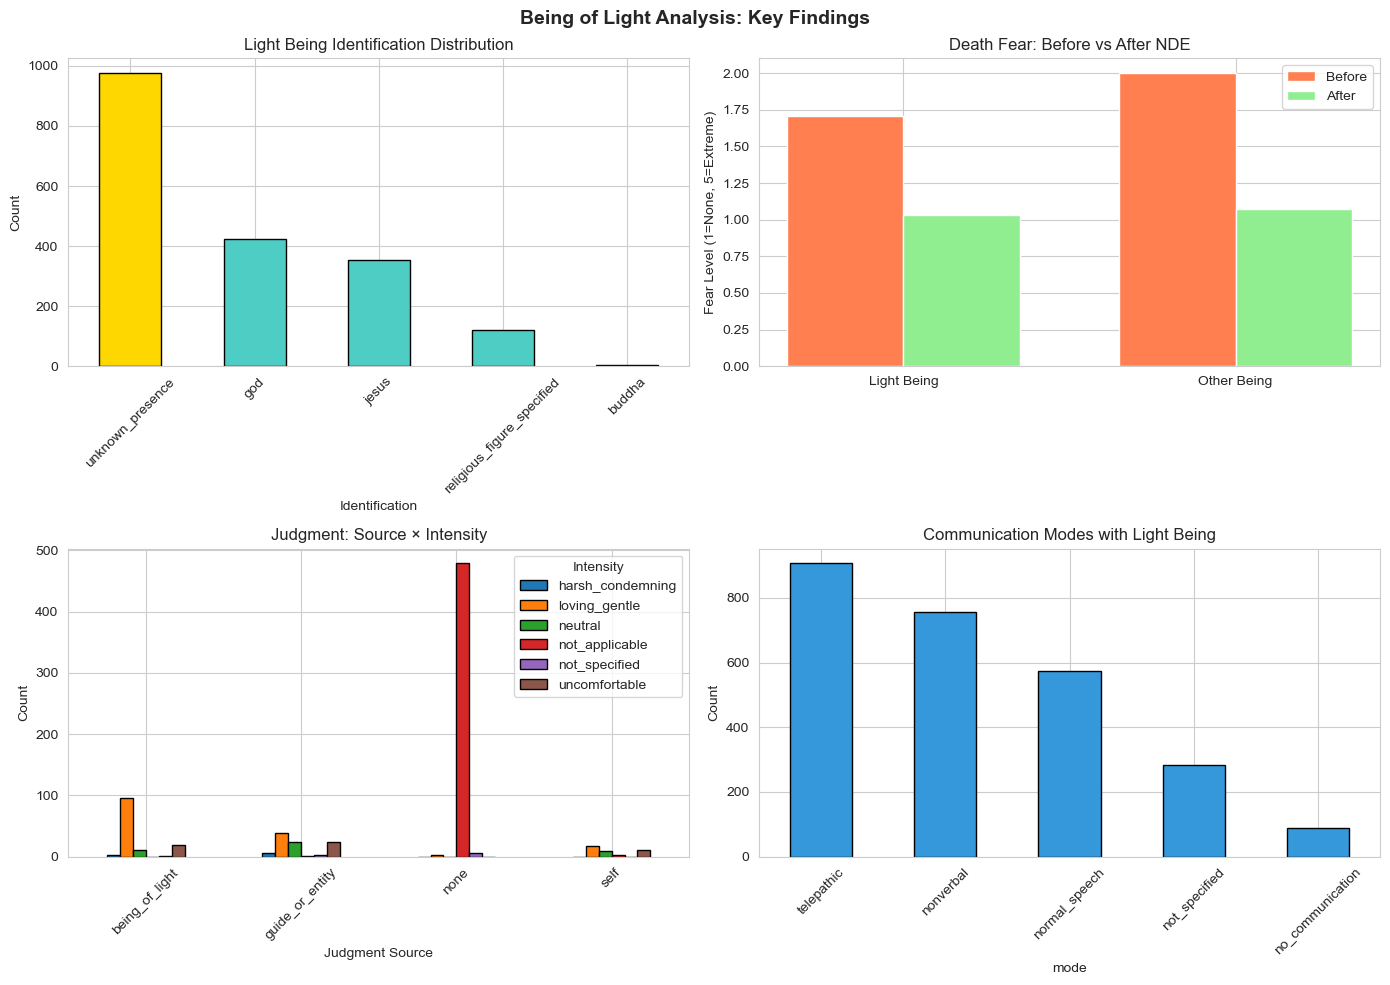


✓ Figure saved: ../output/01_being_of_light_summary.png


In [52]:
# =============================================================================
# VISUALIZATION: Key Findings Summary
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Being of Light Analysis: Key Findings', fontsize=14, fontweight='bold')

# 1. Identification Distribution
ax1 = axes[0, 0]
id_counts = light_being_df['primary_identification'].value_counts().head(5)
colors = ['#FFD700' if x == 'unknown_presence' else '#4ECDC4' for x in id_counts.index]
id_counts.plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Light Being Identification Distribution')
ax1.set_xlabel('Identification')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# 2. Death Fear Before/After
ax2 = axes[0, 1]
if 'fear_df' in dir() and fear_df is not None and len(fear_df) > 0:
    fear_summary = fear_df.groupby('group').agg({
        'before_num': 'mean',
        'after_num': 'mean'
    }).reset_index()
    
    x = range(len(fear_summary))
    width = 0.35
    ax2.bar([i - width/2 for i in x], fear_summary['before_num'], width, label='Before', color='coral')
    ax2.bar([i + width/2 for i in x], fear_summary['after_num'], width, label='After', color='lightgreen')
    ax2.set_xticks(x)
    ax2.set_xticklabels(fear_summary['group'])
    ax2.set_ylabel('Fear Level (1=None, 5=Extreme)')
    ax2.set_title('Death Fear: Before vs After NDE')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Death Fear: Before vs After NDE')

# 3. Judgment Analysis using DataFrame
ax3 = axes[1, 0]
judgment_df = light_being_df[['judgment_source', 'judgment_intensity']].copy()
judgment_df = judgment_df[(judgment_df['judgment_source'] != 'not_mentioned') & 
                          (judgment_df['judgment_intensity'] != 'not_mentioned')]

if len(judgment_df) > 10:
    crosstab = pd.crosstab(judgment_df['judgment_source'], judgment_df['judgment_intensity'])
    crosstab.plot(kind='bar', ax=ax3, edgecolor='black')
    ax3.set_title('Judgment: Source × Intensity')
    ax3.set_xlabel('Judgment Source')
    ax3.set_ylabel('Count')
    ax3.tick_params(axis='x', rotation=45)
    ax3.legend(title='Intensity')
else:
    ax3.text(0.5, 0.5, 'Insufficient judgment data', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Judgment: Source × Intensity')

# 4. Communication Mode Distribution
ax4 = axes[1, 1]
if 'light_modes' in dir() and light_modes is not None and len(light_modes) > 0:
    light_modes.head(5).plot(kind='bar', ax=ax4, color='#3498db', edgecolor='black')
    ax4.set_title('Communication Modes with Light Being')
    ax4.set_ylabel('Count')
    ax4.tick_params(axis='x', rotation=45)
else:
    mode_counts = light_being_df['communication_mode'].value_counts().head(5)
    mode_counts.plot(kind='bar', ax=ax4, color='#3498db', edgecolor='black')
    ax4.set_title('Communication Modes with Light Being')
    ax4.set_ylabel('Count')
    ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../output/01_being_of_light_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved: ../output/01_being_of_light_summary.png")

---

# Conclusion: Being of Light Profile Summary

## What We Measured

| Part | Question | Measurement |
|------|----------|-------------|
| **I: Presence** | Does the Being appear? | Encounter rates, cross-demographic consistency |
| **II: Personality** | What is its character? | Judgment intensity, love:harsh ratio |
| **III: Communication** | How does it communicate? | Communication modes, guidance patterns |
| **IV: Identification** | How is it identified? | Cultural vocabulary variation, unknown presence rate |
| **V: Transformation** | What effects does it produce? | Death fear changes, spirituality shifts |

## Key Findings

*[Execute notebook cells to populate findings]*

## Methodological Notes

1. **Valid measurements** — Focus on what the schema can actually capture
2. **Pattern consistency IS evidence** — Reliable patterns across diverse experiencers matter
3. **Removed invalid tests** — No longer count total beings to test "singularity"
4. **Cultural overlay expected** — Vocabulary varies while phenomenon remains constant
5. **Constant reality + variable interpretation** — The phenomenon is consistent; cultural vocabulary is applied after the encounter

---

**Notebook**: `01_being_of_light_analysis.ipynb`  
**Schema Version**: 2026-01-06  
**Restructured**: January 6, 2026